In [1]:
import model
import data

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader

from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
# device="mps"
## Load Dataset
train_dataset = data.InverseData(mat_file="../Data/NEDC_lite.mat", outputs_npy="../Data/outputs_train.npy", ks_npy="../Data/ks_train.npy")
val_dataset = data.InverseData(mat_file="../Data/NEDC_lite.mat", outputs_npy="../Data/outputs_val.npy", ks_npy="../Data/ks_val.npy")
test_dataset = data.InverseData(mat_file="../Data/NEDC_lite.mat", outputs_npy="../Data/outputs_test.npy", ks_npy="../Data/ks_test.npy")

# train_dataset = train_dataset.to(device)
# val_dataset = val_dataset.to(device)
# test_dataset = test_dataset.to(device)

train_loader = DataLoader(train_dataset, batch_size=50, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=100, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

In [2]:
best_arch = "./checkpoints/model_lr0.001_nl2_p64_wd0.0_best.pth"
m = model.OperatorNetwork(trunk_input_size=7, branch_input_size=6, num_layers=2, p =64)
m.load_state_dict(torch.load(best_arch)["model_state_dict"])

C:\Users\Lohith\AppData\Local\Temp\ipykernel_26400\4092209722.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  m.load_state_dict(torch.load(best_arch)["model_state_dict"]

<All keys matched successfully>

In [3]:
with torch.no_grad():
    for batch in tqdm(test_loader):
        A, seq, out = batch
        # seq, A, out = seq.to(device), A.to(device), out.to(device)
        predictions = m(seq=seq, A=A)
        

100%|██████████| 1/1 [00:09<00:00,  9.52s/it]


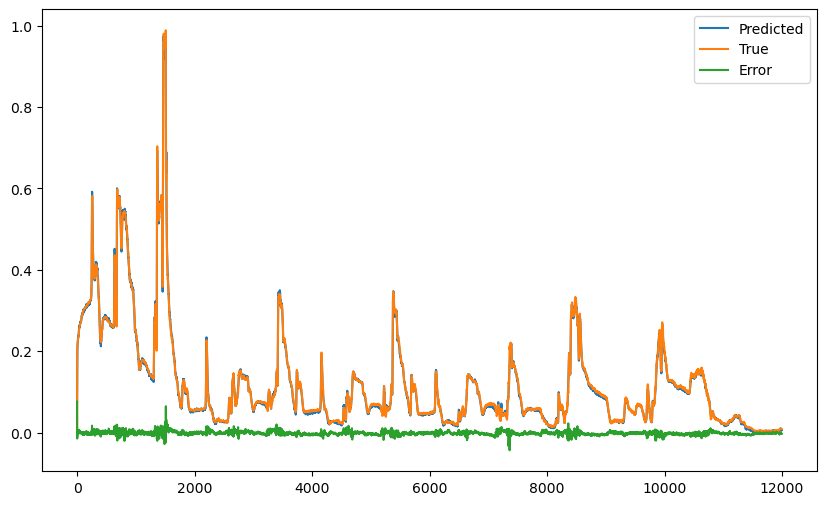

In [4]:
import matplotlib.pyplot as plt

index = 10

plt.figure(figsize=(10, 6))
plt.plot(predictions[index].cpu().numpy(), label="Predicted")
plt.plot(out[index].cpu().numpy(), label="True")
plt.plot(predictions[index].cpu().numpy() - out[index].cpu().numpy(), label="Error")
plt.legend()

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm
import numpy as np

def optimize_inverse_parameters(trunk_input, target_output, model, lr=0.05, inv_epochs=1000, patience=50, means=None, stds=None, device='cpu'):
    """
    Runs inverse modeling on a frozen DeepONet to find the optimal Branch inputs (A values)
    across the entire unmasked sequence.
    """
    
    # 1. Freeze model weights
    model.eval()
    for param in model.parameters():
        param.requires_grad = False

    # 2. Move data to device
    trunk_input = trunk_input.unsqueeze(0).to(device)
    target_output = target_output.unsqueeze(0).to(device)

    # 3. Pre-compute Trunk basis
    print("Pre-computing Trunk basis functions...")
    with torch.no_grad():
        basis = model.trunk(trunk_input)

    # 4. Initialize A_guess
    A_guess = nn.Parameter(torch.randn(1, 6, device=device))

    optimizer_inv = torch.optim.Adam([A_guess], lr=lr)
    criterion = nn.MSELoss()

    best_inv_loss = float('inf')
    epochs_no_improve = 0
    best_A = None

    pbar = tqdm(range(inv_epochs), desc="Optimizing A values")

    # 5. Optimization Loop
    for step in pbar:
        optimizer_inv.zero_grad()

        coeff = model.branch(A_guess)
        
        # Recombine basis and coeff
        pred = torch.einsum('btp,bp->bt', basis, coeff).unsqueeze(-1) 

        # Calculate loss directly on the full sequences
        loss = criterion(pred, target_output)
        
        loss.backward()
        optimizer_inv.step()

        current_loss = loss.item()
        pbar.set_postfix({'Loss': f"{current_loss:.6f}"})

        if current_loss < best_inv_loss:
            best_inv_loss = current_loss
            best_A = A_guess.detach().clone()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            
        if epochs_no_improve >= patience:
            pbar.write(f"Early stopping triggered at step {step}.")
            break

    print(f"\nOptimization Complete! Best Loss: {best_inv_loss:.6f}")
    
    if best_A is None:
        return None, None

    # 6. Un-normalize
    final_A_normalized = best_A.cpu().flatten()
    
    if means is not None and stds is not None:
        final_A = (final_A_normalized * stds) + means
        return final_A
    else:
        print("Means and standard deviations not provided; skipping physical un-normalization.")
        return final_A_normalized

In [11]:
A_guess = optimize_inverse_parameters(trunk_input=seq[0], target_output=out[0], model=m, lr=0.05, inv_epochs=1000, patience=100, means=None, stds=None, device="cpu")

Pre-computing Trunk basis functions...


Optimizing A values:  54%|█████▎    | 537/1000 [00:01<00:01, 320.28it/s, Loss=0.000008]

Early stopping triggered at step 537.

Optimization Complete! Best Loss: 0.000008
Means and standard deviations not provided; skipping physical un-normalization.


In [12]:
A[0], A_guess

(tensor([-0.1965,  0.4459,  0.6883,  0.2691,  0.5805, -1.4933]),
 tensor([ 2.0433, -0.1511,  0.5649,  0.0157,  0.1840, -0.0862]))

In [13]:
recon_with_A_guess = m(seq=seq[0].unsqueeze(0), A=A_guess.unsqueeze(0))
recon_with_A_act = m(seq=seq[0].unsqueeze(0), A=A[0].unsqueeze(0))


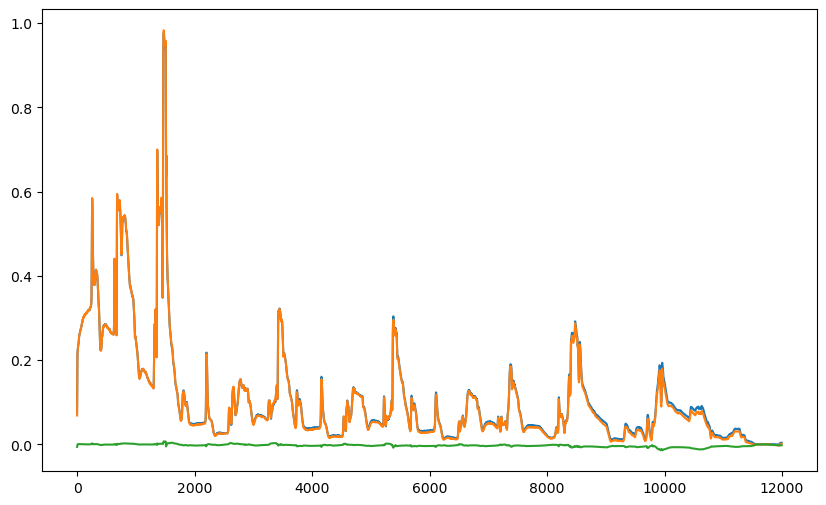

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(recon_with_A_guess.cpu().numpy().flatten(), label="Reconstruction with A_guess")
plt.plot(recon_with_A_act.cpu().numpy().flatten(), label="Reconstruction with A_actual")
plt.plot(recon_with_A_act.cpu().numpy().flatten() - recon_with_A_guess.cpu().numpy().flatten(), label="Difference")
# plt.plot(out[0].cpu().numpy().flatten(), label="True Output", linestyle='dashed')